#### 1. Import Library

In [1]:
!pip install seaborn opencv-python

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50
import tensorflow.keras.backend as K
import gc

#### 2. Dataset Path

In [4]:
dataset_path = "/content/drive/MyDrive/Dataset/fall_dataset"

#### 3. LOAD DATASET

In [5]:
def load_dataset():
    images = []
    labels = []

    image_dir = os.path.join(dataset_path, "images", "train")
    label_dir = os.path.join(dataset_path, "labels", "train")

    size = (256, 256)

    for file in os.listdir(image_dir):
        img_path = os.path.join(image_dir, file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, size)
        images.append(img)

        label_file = file[:-4] + ".txt"
        label_path = os.path.join(label_dir, label_file)

        if not os.path.exists(label_path):
            continue

        with open(label_path, "r") as f:
            line = f.readline().strip().split()
            if len(line) == 0:
                continue

            label = int(float(line[0]))

            if label == 2:
                label = 1

            labels.append(label)

    return np.array(images), np.array(labels)


images, labels = load_dataset()

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: (374, 256, 256, 3)
Labels: (374,)


#### 4. Preprocess data

In [6]:
def preprocess(images, labels):
    X_train, X_test, y_train, y_test = train_test_split(
        images, labels,
        test_size=0.2,
        random_state=42,
        stratify=labels
    )

    X_train = X_train.astype("float32") / 255.0
    X_test = X_test.astype("float32") / 255.0

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = preprocess(images, labels)

#### 5. Data Augumentation

In [7]:
data_augmentor = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

data_augmentor.fit(X_train)

#### 6. MEMORY CLEAN FUNCTION

In [8]:
def clear_memory():
    K.clear_session()
    gc.collect()

#### 7. TRAINING FUNCTION

In [9]:
def train_model(model, name):
    print(f"\n===== Training {name} =====\n")

    history = model.fit(
        data_augmentor.flow(X_train, y_train, batch_size=32),
        validation_data=(X_test, y_test),
        epochs=30,
        verbose=1
    )

    preds = (model.predict(X_test) > 0.5).astype(int)

    print(f"\n{name} Classification Report")
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return model

#### 8. Model Ctreation

In [10]:
input_shape = X_train[0].shape
num_classes = 1 # For binary classification

##### 8.1. Custom CNN

In [11]:
def create_fall_detection_cnn(input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid') # Binary classification output
    ])

    model.compile(optimizer=Adam(1e-4), # Kept original optimizer
                  loss='binary_crossentropy', # Binary classification loss
                  metrics=['accuracy'])
    return model

# Create the model and print summary
cnn_model = create_fall_detection_cnn(input_shape)
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,105 (56.61 MB)

 Trainable params: 14,839,105 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

##### 8.2. MobileNetV2

In [12]:
def create_mobilenet_model(input_shape):
    base = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(optimizer=Adam(1e-4),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

# Create the model and print summary
mobilenet_model = create_mobilenet_model(input_shape)
mobilenet_model.summary()

/tmp/ipykernel_38074/4065936857.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

##### 8.3. EfficientNetB0

In [13]:
def create_efficientnet_model(input_shape):
    base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = True

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(optimizer=Adam(1e-4),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

# Create the model and print summary
efficientnet_model = create_efficientnet_model(input_shape)
efficientnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 4,171,645 (15.91 MB)

 Non-trainable params: 42,023 (164.16 KB)

##### 8.4. ResNet50

In [14]:
def create_resnet_model(input_shape):
    base = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(optimizer=Adam(1e-4),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

# Create the model and print summary
resnet_model = create_resnet_model(input_shape)
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

#### 9. Train Models

##### 9.1. CNN


===== Training Custom CNN =====

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 60s 6s/step - accuracy: 0.5217 - loss: 0.7189 - val_accuracy: 0.5600 - val_loss: 0.6895
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 84s 6s/step - accuracy: 0.5619 - loss: 0.6968 - val_accuracy: 0.5733 - val_loss: 0.6828
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 57s 6s/step - accuracy: 0.5385 - loss: 0.6909 - val_accuracy: 0.5600 - val_loss: 0.6798
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 58s 6s/step - accuracy: 0.5686 - loss: 0.6810 - val_accuracy: 0.5467 - val_loss: 0.6731
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 57s 6s/step - accuracy: 0.6388 - loss: 0.6644 - val_accuracy: 0.5467 - val_loss: 0.6747
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 58s 6s/step - accuracy: 0.6020 - loss: 0.6729 - val_accuracy: 0.5600 - val_loss: 0.6571
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 70s 7s/step - accuracy: 0.6355 - loss: 0.6560 - val_accuracy: 0.6933 - val_loss: 0.6473
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 58s 6s/step - accuracy: 0.6522 - loss: 0.6341 

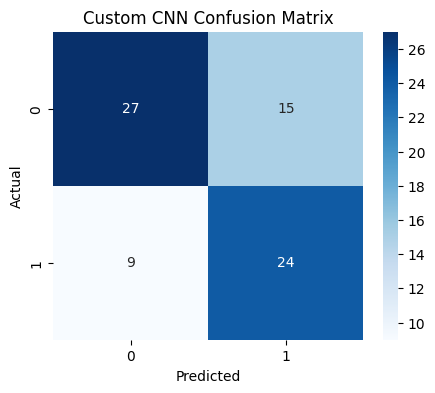

In [15]:
model = create_fall_detection_cnn(input_shape)
model = train_model(model, "Custom CNN")
model.save(os.path.join(dataset_path, "cnn_model.h5"))

clear_memory()

##### 9.2. MobileNet RUN

/tmp/ipykernel_38074/4065936857.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)



===== Training MobileNetV2 =====

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.5719 - loss: 0.7273 - val_accuracy: 0.6400 - val_loss: 0.6552
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.6455 - loss: 0.6314 - val_accuracy: 0.6800 - val_loss: 0.6089
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.6923 - loss: 0.5694 - val_accuracy: 0.7467 - val_loss: 0.5689
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.7559 - loss: 0.5211 - val_accuracy: 0.7600 - val_loss: 0.5370
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.7191 - loss: 0.5214 - val_accuracy: 0.7600 - val_loss: 0.5084
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.7625 - loss: 0.4824 - val_accuracy: 0.7867 - val_loss: 0.4927
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.8328 - loss: 0.4214 - val_accuracy: 0.7867 - val_loss: 0.4622
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.8027 - loss: 0.4345

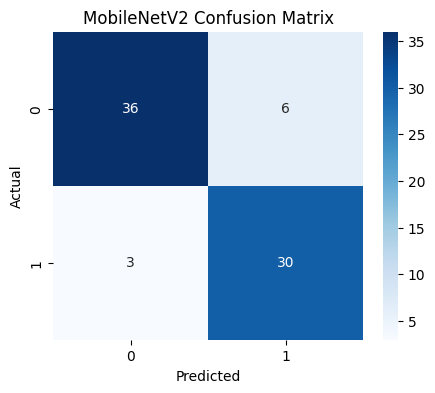

In [16]:
model = create_mobilenet_model(input_shape)
model = train_model(model, "MobileNetV2")
model.save(os.path.join(dataset_path, "mobilenet_model.h5"))

clear_memory()

##### 9.3. EfficientNet RUN


===== Training EfficientNetB0 =====

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 201s 15s/step - accuracy: 0.5619 - loss: 0.6624 - val_accuracy: 0.5600 - val_loss: 0.6881
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 139s 14s/step - accuracy: 0.7291 - loss: 0.5520 - val_accuracy: 0.5600 - val_loss: 0.7003
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 140s 14s/step - accuracy: 0.8395 - loss: 0.4598 - val_accuracy: 0.5600 - val_loss: 0.6969
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 143s 14s/step - accuracy: 0.8763 - loss: 0.3965 - val_accuracy: 0.5600 - val_loss: 0.6914
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 153s 16s/step - accuracy: 0.8829 - loss: 0.3462 - val_accuracy: 0.5600 - val_loss: 0.6890
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 195s 14s/step - accuracy: 0.9231 - loss: 0.2648 - val_accuracy: 0.5600 - val_loss: 0.6868
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 137s 14s/step - accuracy: 0.9164 - loss: 0.2375 - val_accuracy: 0.5600 - val_loss: 0.6858
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 143s 14s/step - accuracy: 0.

2/3 ━━━━━━━━━━━━━━━━━━━━ 2s 3s/step 

3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step

EfficientNetB0 Classification Report
              precision    recall  f1-score   support

           0       0.62      0.19      0.29        42
           1       0.45      0.85      0.59        33

    accuracy                           0.48        75
   macro avg       0.53      0.52      0.44        75
weighted avg       0.54      0.48      0.42        75



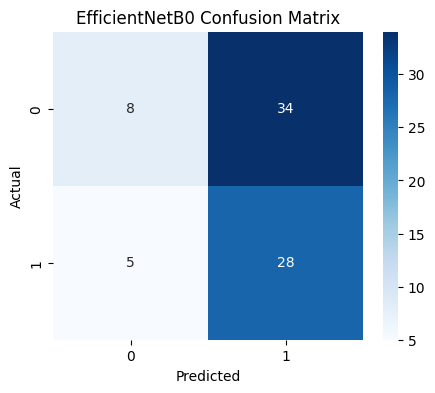

In [17]:
model = create_efficientnet_model(input_shape)
model = train_model(model, "EfficientNetB0")
model.save(os.path.join(dataset_path, "efficientnet_model.h5"))

clear_memory()

##### 9.4. ResNet


===== Training ResNet50 =====

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 138s 13s/step - accuracy: 0.5184 - loss: 0.8189 - val_accuracy: 0.5600 - val_loss: 0.6988
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 107s 11s/step - accuracy: 0.5719 - loss: 0.7428 - val_accuracy: 0.5600 - val_loss: 0.6799
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 141s 11s/step - accuracy: 0.5217 - loss: 0.7172 - val_accuracy: 0.6933 - val_loss: 0.6789
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 104s 11s/step - accuracy: 0.4916 - loss: 0.7526 - val_accuracy: 0.5867 - val_loss: 0.6676
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 120s 12s/step - accuracy: 0.6087 - loss: 0.6898 - val_accuracy: 0.5733 - val_loss: 0.6691
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 105s 11s/step - accuracy: 0.5619 - loss: 0.7129 - val_accuracy: 0.5733 - val_loss: 0.6664
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 143s 11s/step - accuracy: 0.5585 - loss: 0.7034 - val_accuracy: 0.5733 - val_loss: 0.6654
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 105s 11s/step - accuracy: 0.5853 -

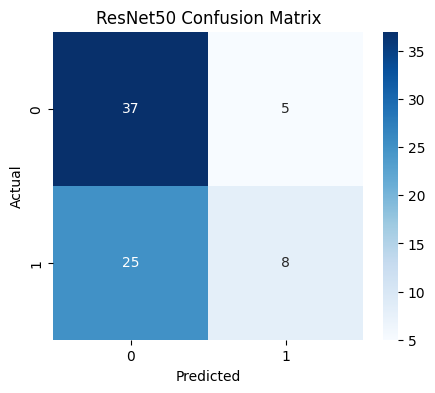

In [18]:
model = create_resnet_model(input_shape)
model = train_model(model, "ResNet50")
model.save(os.path.join(dataset_path, "resnet_model.h5"))

clear_memory()

#### 10. Model Comparison

In [19]:
from tensorflow.keras.models import load_model

models = {
    "CNN": load_model(os.path.join(dataset_path, "cnn_model.h5")),
    "MobileNetV2": load_model(os.path.join(dataset_path, "mobilenet_model.h5")),
    "EfficientNetB0": load_model(os.path.join(dataset_path, "efficientnet_model.h5")),
    "ResNet50": load_model(os.path.join(dataset_path, "resnet_model.h5"))
}

results = {}

for name, model in models.items():
    preds = (model.predict(X_test) > 0.5).astype(int)
    acc = accuracy_score(y_test, preds)
    results[name] = acc

print("\n===== FINAL MODEL COMPARISON =====")
for k, v in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{k}: {v:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 914ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 7s/step

===== FINAL MODEL COMPARISON =====
MobileNetV2: 0.8800
CNN: 0.6800
ResNet50: 0.6000
EfficientNetB0: 0.5600


/tmp/ipykernel_38074/3228771742.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


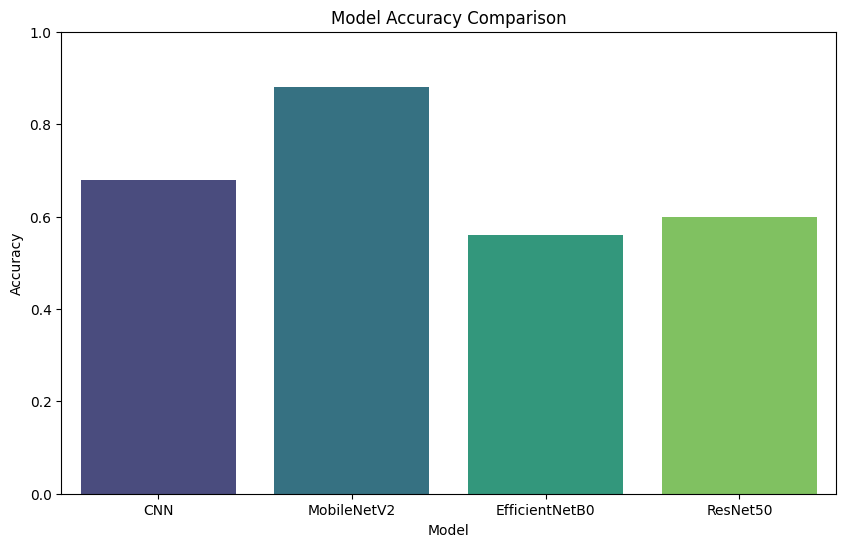

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.show()

#### 11. Save Best Model

In [21]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

Best Model: MobileNetV2
